In [1]:
import requests
from requests.packages.urllib3.exceptions import InsecureRequestWarning

# Silenciar las advertencias de conexión insegura
requests.packages.urllib3.disable_warnings(InsecureRequestWarning)
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

API_URL = "https://rsm.ane.gov.co:12443/api"

camp_ids = {'no dc, no iq': 202, 'no dc, yes iq': 203, 'yes dc, yes iq': 204, 'FM original': 176}
macs_node = {
    '1': 'd8:3a:dd:f7:1d:f2', '3': 'd8:3a:dd:f7:22:87', 
    '2': 'd8:3a:dd:f4:4e:26', '5': 'd8:3a:dd:f7:21:52', 
    '9': 'd8:3a:dd:f4:4e:d1'
}

def get_api_signals(mac, camp_id):
    url = f"{API_URL}/campaigns/sensor/{mac}/signals"
    params = {"campaign_id": camp_id, "page": 1, "page_size": 5000}
    signals = []
    
    while True:
        data = requests.get(url, params=params, verify=False).json()
        signals.extend(data['measurements'])
        
        if not data['pagination']['has_next']:
            break
        params['page'] += 1
        
    return signals

# 1. CARGA DIRECTA
df_full = {rbw: {} for rbw in camp_ids}

with tqdm(total=len(camp_ids) * len(macs_node), desc="Descargando API") as pbar:
    for rbw, camp_id in camp_ids.items():
        for node, mac in macs_node.items():
            datos = get_api_signals(mac, camp_id)
            if datos:
                df = pd.DataFrame(datos)
                df = df.dropna(subset=['pxx'])
                df_full[rbw][f"Node{node}"] = df
            pbar.update(1)

Descargando API: 100%|██████████| 20/20 [01:23<00:00,  4.16s/it]


# Example plot campaign no dc, no iq, first row:

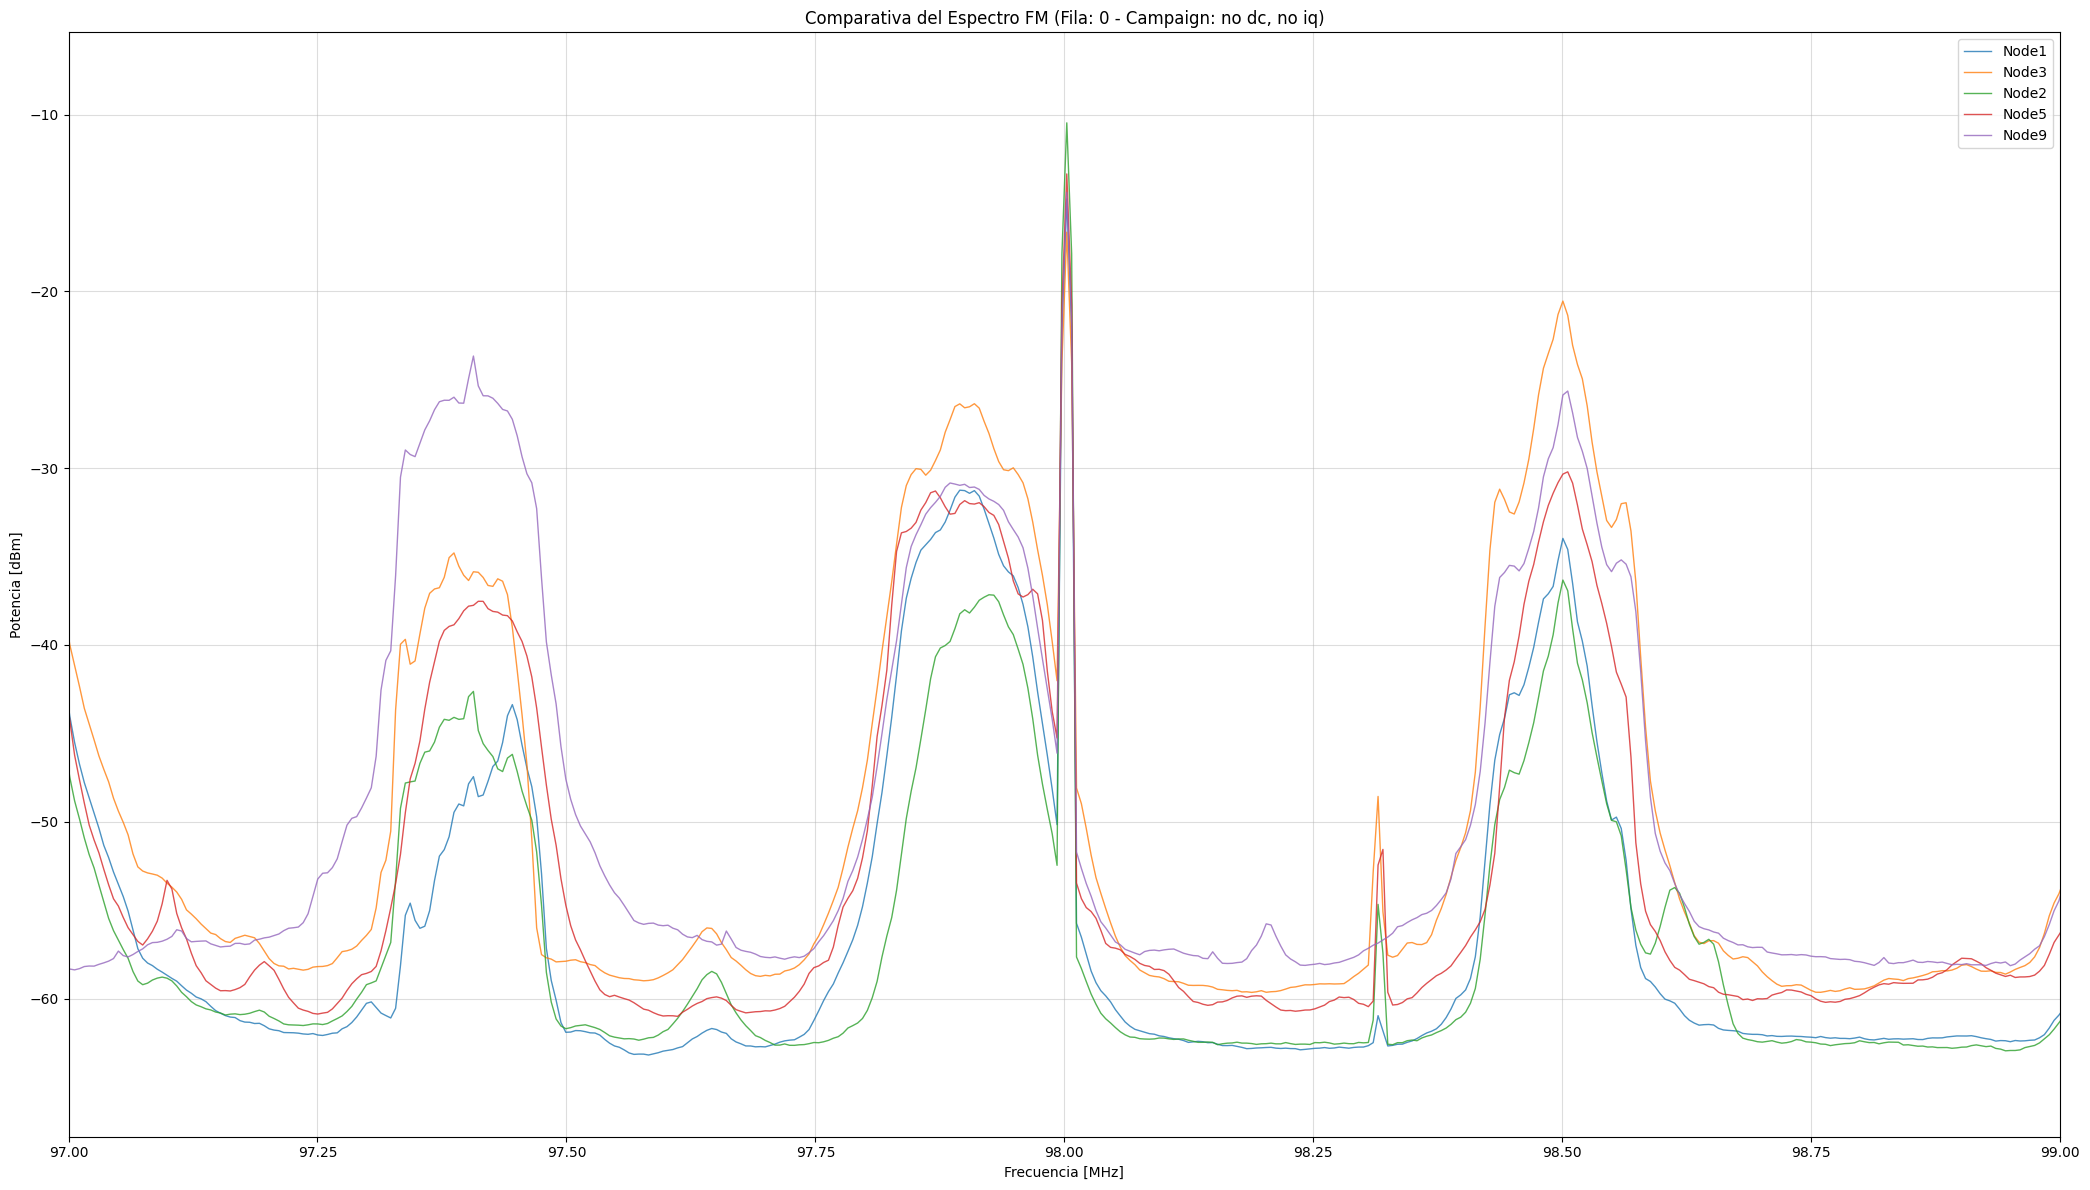

In [2]:
campaign_data = "no dc, no iq"  
datos_nodos = df_full[campaign_data]
ROW_PLOT = 0  

plt.figure(figsize=(21, 12))

for nombre_nodo, df in datos_nodos.items():
    if ROW_PLOT < len(df):
        fila = df.iloc[ROW_PLOT]
        pxx = fila['pxx']
        
        # Aprovechamos las frecuencias reales del payload
        f_start = fila['start_freq_hz'] / 1e6
        f_end = fila['end_freq_hz'] / 1e6
        frecuencias = np.linspace(f_start, f_end, len(pxx))
        
        plt.plot(frecuencias, pxx, label=nombre_nodo, linewidth=1, alpha=0.8)

plt.title(f"Comparativa del Espectro FM (Fila: {ROW_PLOT} - Campaign: {campaign_data})")
plt.xlabel("Frecuencia [MHz]")
plt.ylabel("Potencia [dBm]")
plt.legend(loc='best')
plt.xlim(97, 99)
plt.grid(True, alpha=0.42)
plt.tight_layout()
plt.show()

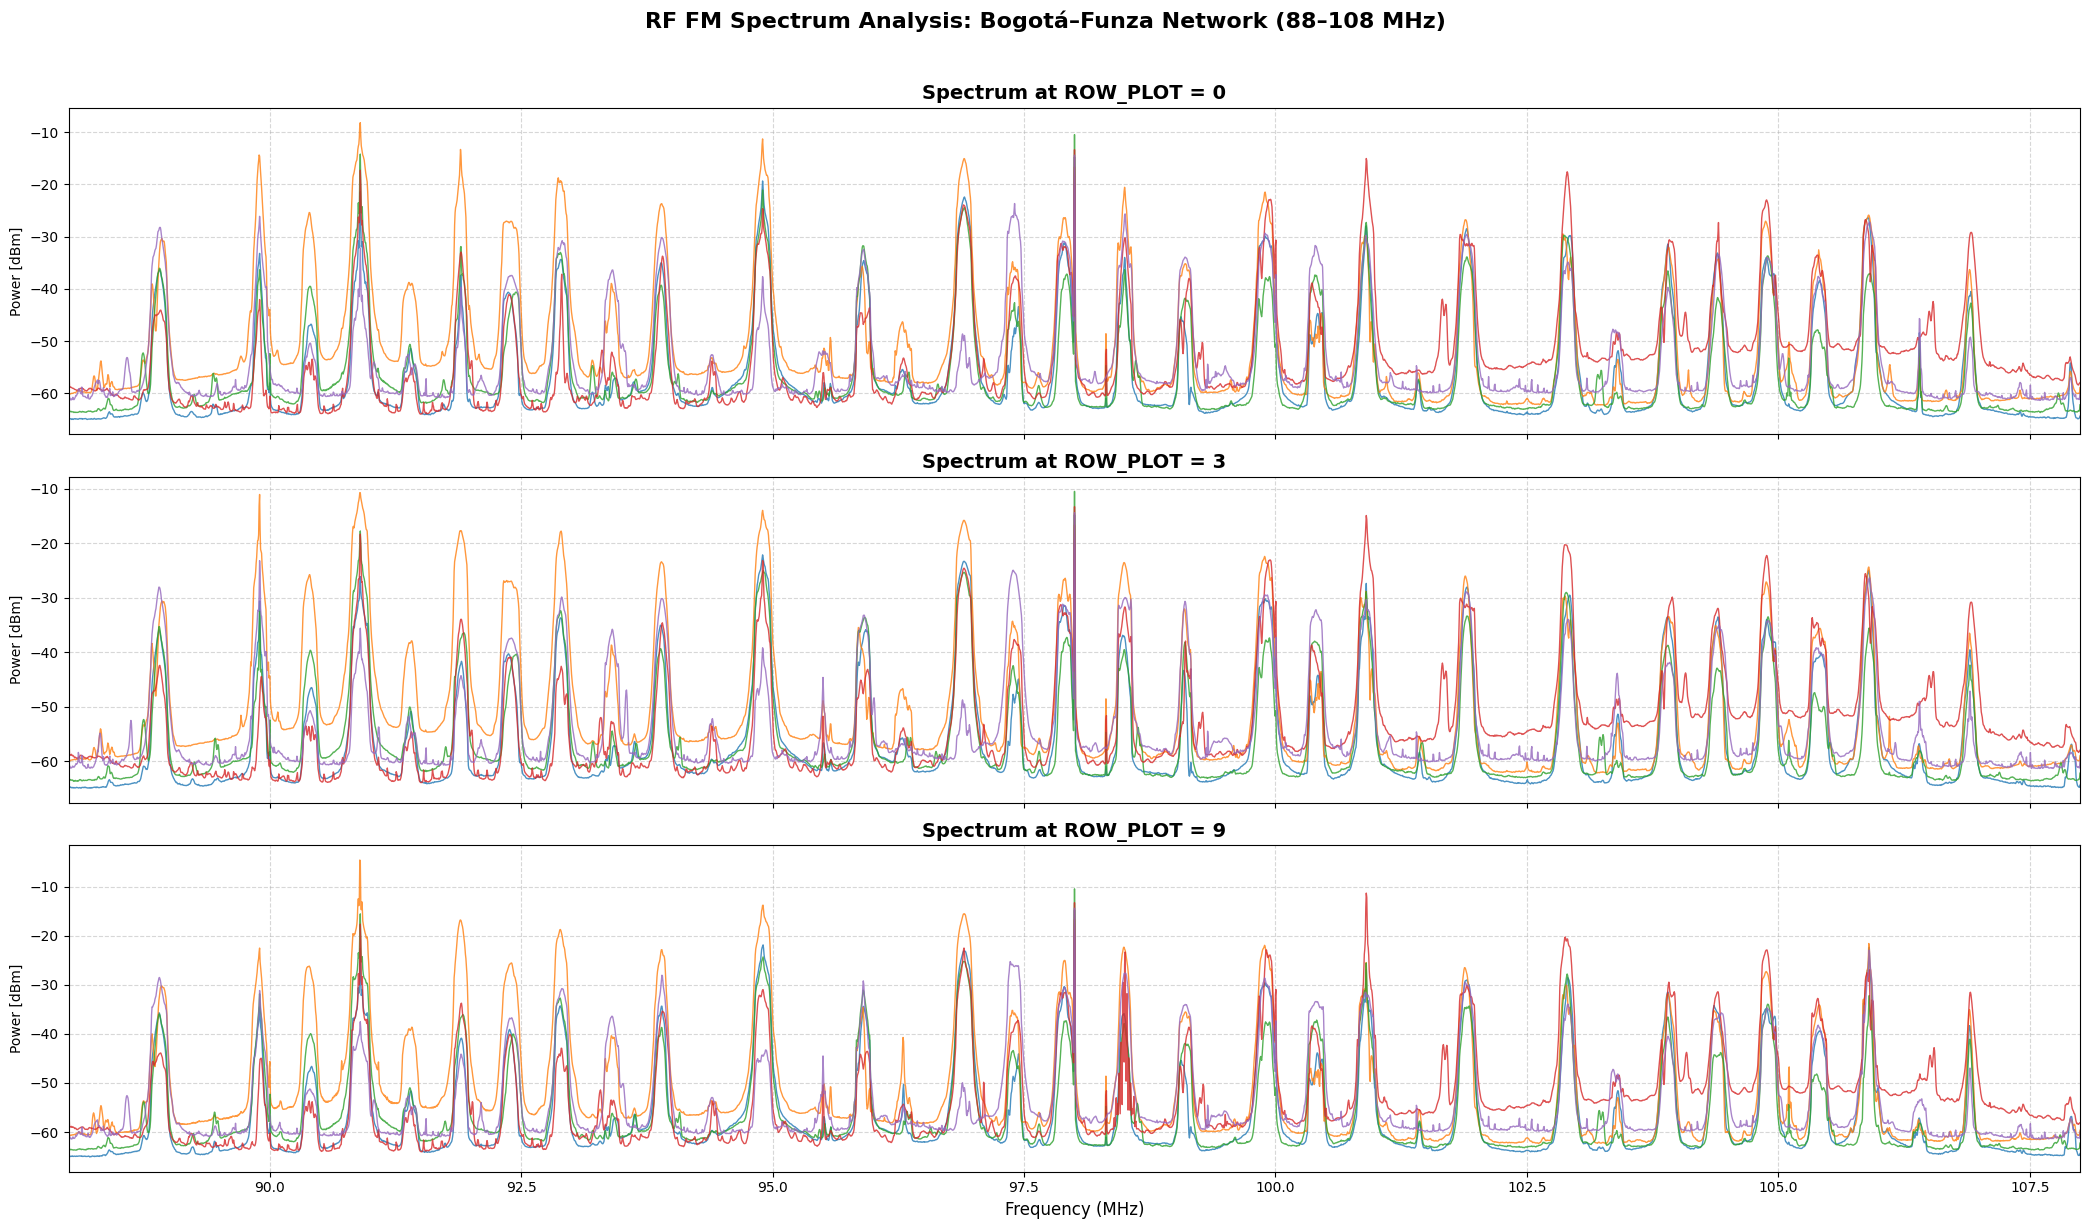

In [3]:
# Row indices to plot
row_indices = [0, 3, 9]

# Create figure with 3 subplots (one per ROW_PLOT value)
fig, axes = plt.subplots(nrows=len(row_indices), ncols=1, figsize=(21, 12), sharex=True)

# Ensure axes is iterable even if only one row
if len(row_indices) == 1:
    axes = [axes]

for ax, row_idx in zip(axes, row_indices):
    
    for nombre_nodo, df in datos_nodos.items():
        # ⚠️ Safety check
        if row_idx >= len(df):
            continue
            
        # SOLUCIÓN: Extraer los datos de la fila actual del nodo actual
        pxx = df['pxx'].iloc[row_idx] 
        
        # Ahora frecuencias se calcula con el tamaño real de pxx de este nodo
        frecuencias = np.linspace(88, 108, len(pxx)) 
        
        # Plot spectrum for this node
        ax.plot(frecuencias, pxx, label=nombre_nodo, linewidth=1, alpha=0.8)
    
    # Configuración de cada subplot
    ax.set_title(f'Spectrum at ROW_PLOT = {row_idx}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Power [dBm]', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(88, 108)
    # Si quieres ver quién es quién, descomenta la leyenda:
    # ax.legend(loc='upper right', fontsize=8)

# Common x-axis label and title for the entire figure
axes[-1].set_xlabel('Frequency (MHz)', fontsize=12)
fig.suptitle('RF FM Spectrum Analysis: Bogotá–Funza Network (88–108 MHz)', 
             fontsize=16, fontweight='bold', y=1.02)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Procesando no dc, no iq: 100%|██████████| 13/13 [00:00<00:00, 124.84it/s]
/tmp/ipykernel_124099/2598407071.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_nodes)



📊 Resultados para RBW: no dc, no iq
--------------------------------------------------
1   | Node1                | Score: 3.4853 | Corr: 0.8713
2   | Node2                | Score: 3.4188 | Corr: 0.8547
3   | Node3                | Score: 3.2544 | Corr: 0.8136
4   | Node9                | Score: 3.0848 | Corr: 0.7712
5   | Node5                | Score: 3.0298 | Corr: 0.7575


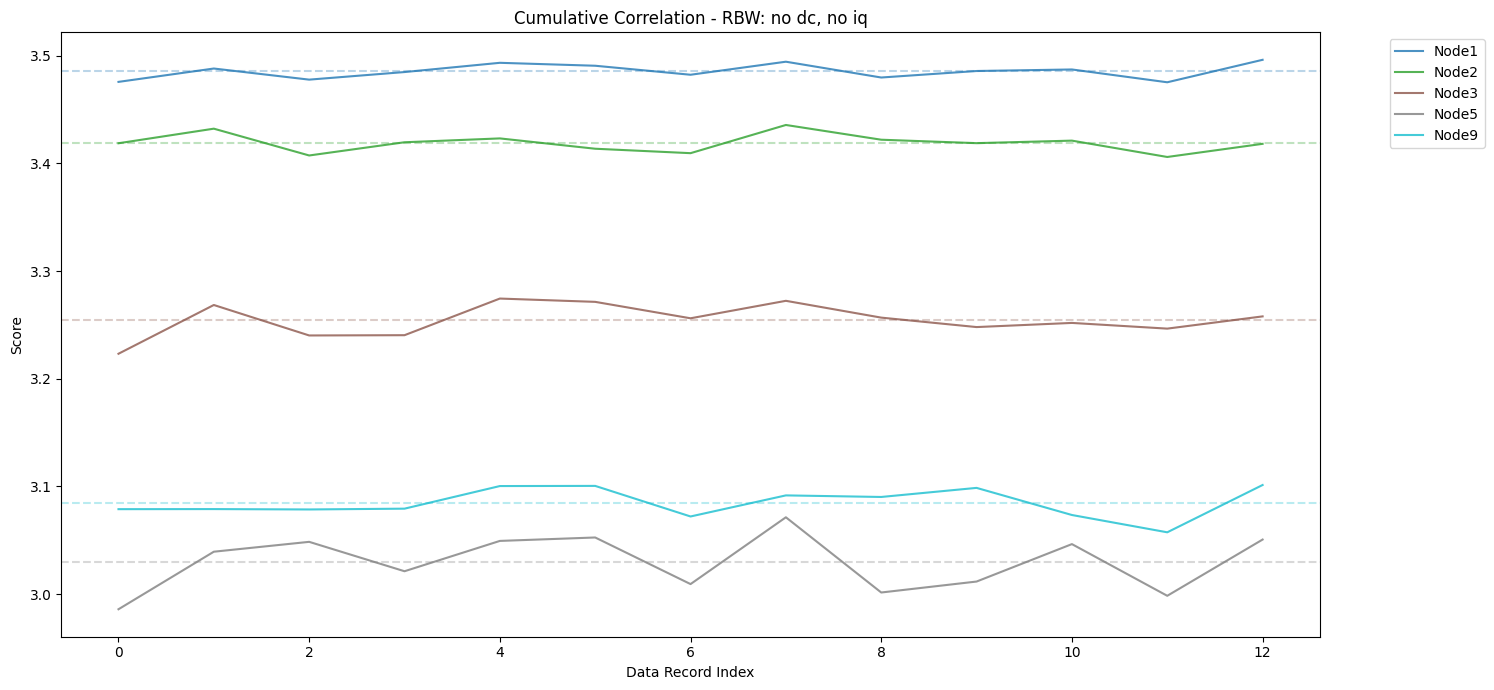

In [4]:
from scipy.stats import pearsonr

# 1. SELECCIÓN DE DATOS
campaign_data = "no dc, no iq"  # <--- Cambia aquí el RBW que quieras analizar
datos_nodos = df_full[campaign_data]

# Determinar número de registros válidos para TODOS los nodos
num_records = min(len(df) for df in datos_nodos.values())

all_ranked_scores = {}
all_cumulative_data = []

# =============================================================================
# LOOP: Procesamiento por cada registro
# =============================================================================
for data_record in tqdm(range(num_records), desc=f"Procesando {campaign_data}"):

    pxx_indexed = {}
    noise_floor_estimates = {}

    # ── PASS 1: Noise floor + recentered PSDs ────────────────────────────────
    for nombre_nodo, df in datos_nodos.items():
        # pxx ya es una lista, solo la convertimos a array de numpy
        pxx = np.array(df['pxx'].iloc[data_record]) 
        pxx_indexed[nombre_nodo] = pxx

        counts, bins = np.histogram(pxx, bins=50)
        noise_floor_estimates[nombre_nodo] = bins[np.argmax(counts)]

    global_noise_mean = np.mean(list(noise_floor_estimates.values()))

    pxx_processed = {}
    for nombre_nodo in datos_nodos.keys():
        pxx_orig = pxx_indexed[nombre_nodo]
        offset = global_noise_mean - noise_floor_estimates[nombre_nodo]
        pxx_recentered = pxx_orig + offset
        pxx_processed[nombre_nodo] = (pxx_recentered - np.mean(pxx_recentered)) / (np.std(pxx_recentered) + 1e-8)

    # ── PASS 2: Pairwise Pearson correlation matrix ───────────────────────────
    node_names = sorted(datos_nodos.keys())
    n_nodes = len(node_names)
    corr_matrix = np.eye(n_nodes)

    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            corr_val, _ = pearsonr(pxx_processed[node_names[i]], pxx_processed[node_names[j]])
            corr_matrix[i, j] = corr_matrix[j, i] = corr_val

    # ── PASS 3: Cumulative scores ─────────────────────────────────────────────
    cumulative_scores = np.sum(corr_matrix, axis=1) - 1.0
    
    for node, score in zip(node_names, cumulative_scores):
        all_ranked_scores.setdefault(node, []).append(score)

# =============================================================================
# AVERAGE Y PLOT
# =============================================================================
avg_scores = {node: np.mean(scores) for node, scores in all_ranked_scores.items()}
avg_sorted = dict(sorted(avg_scores.items(), key=lambda x: x[1], reverse=True))

print(f"\n📊 Resultados para RBW: {campaign_data}")
print("-" * 50)
for rank, (node, avg) in enumerate(avg_sorted.items(), 1):
    print(f"{rank:<3} | {node:<20} | Score: {avg:.4f} | Corr: {avg/(n_nodes-1):.4f}")

# Graficar
fig, ax = plt.subplots(figsize=(15, 7))
cmap = plt.cm.get_cmap('tab10', n_nodes)

for idx, node in enumerate(node_names):
    ax.plot(range(num_records), all_ranked_scores[node], label=node, color=cmap(idx), alpha=0.8)
    ax.axhline(y=avg_scores[node], color=cmap(idx), linestyle='--', alpha=0.3)

ax.set_title(f"Cumulative Correlation - RBW: {campaign_data}")
ax.set_xlabel("Data Record Index")
ax.set_ylabel("Score")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot of cummulative pearson of different campaigns

Camp: no dc, no iq (ID: 202): 100%|██████████| 13/13 [00:00<00:00, 84.42it/s]
/tmp/ipykernel_124099/2631878390.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_nodes)


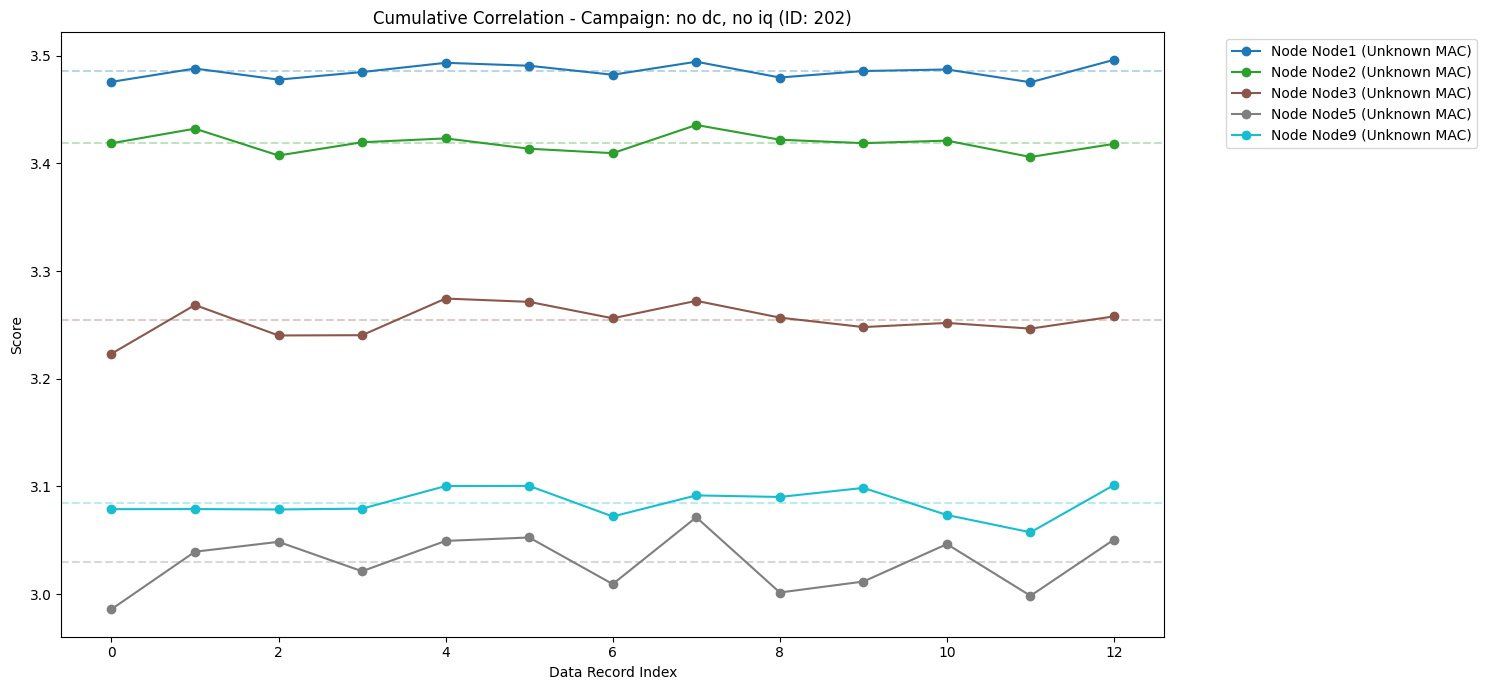

Camp: no dc, yes iq (ID: 203): 100%|██████████| 15/15 [00:00<00:00, 109.85it/s]


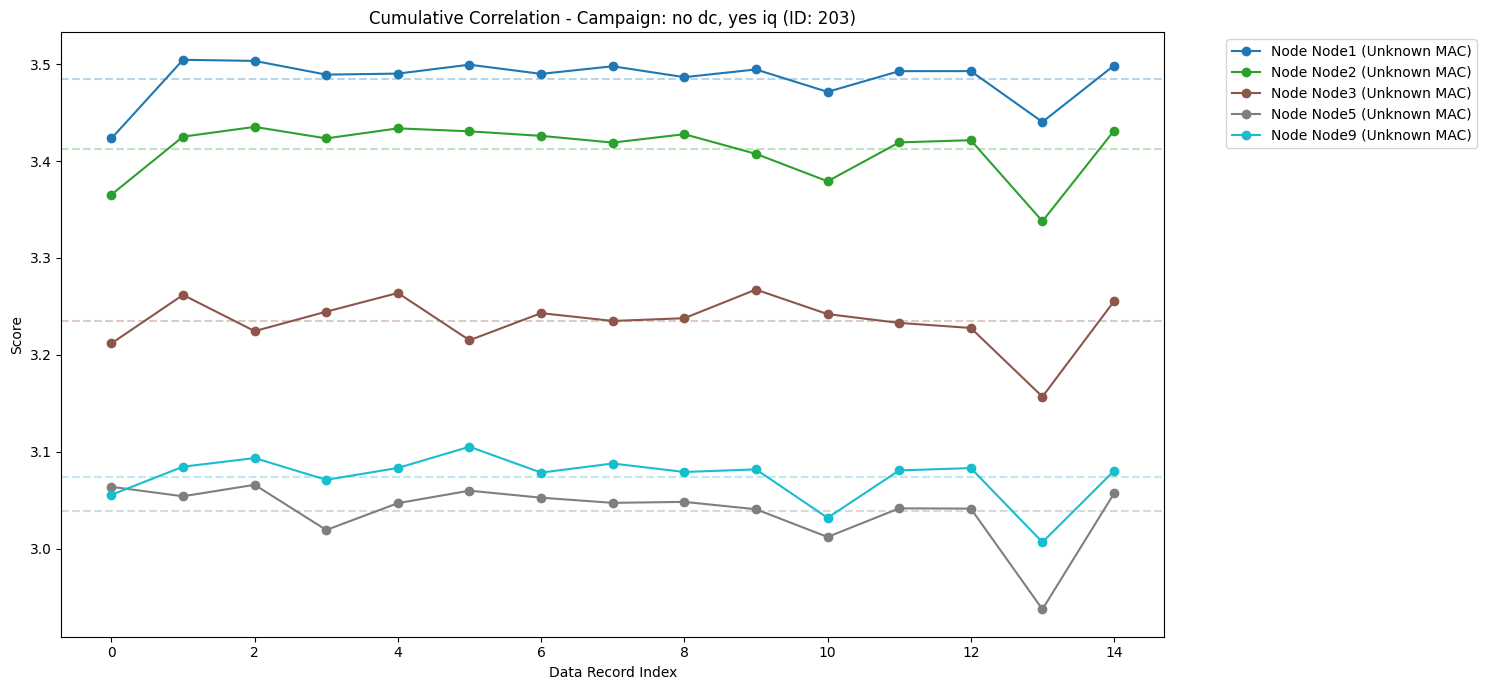

Camp: yes dc, yes iq (ID: 204): 100%|██████████| 15/15 [00:00<00:00, 124.81it/s]


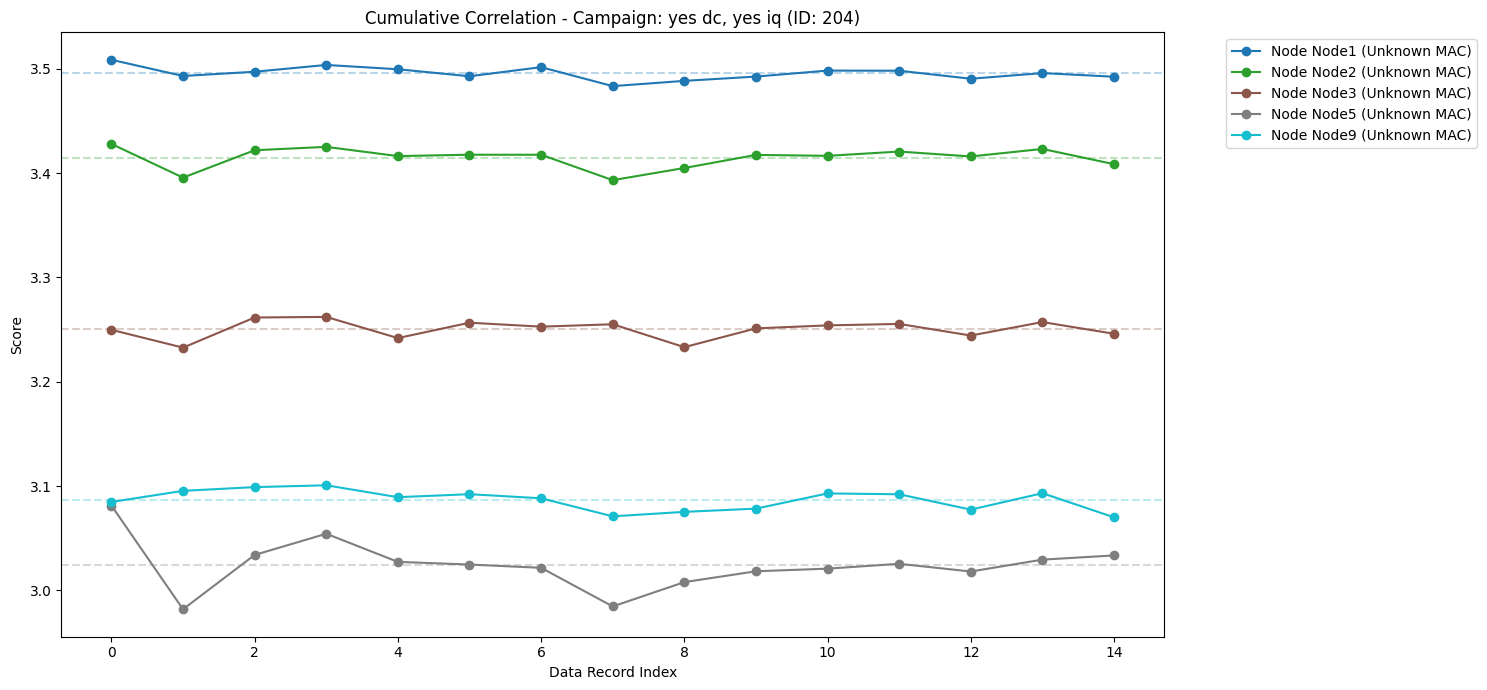

Camp: FM original (ID: 176): 100%|██████████| 105/105 [00:04<00:00, 25.46it/s]


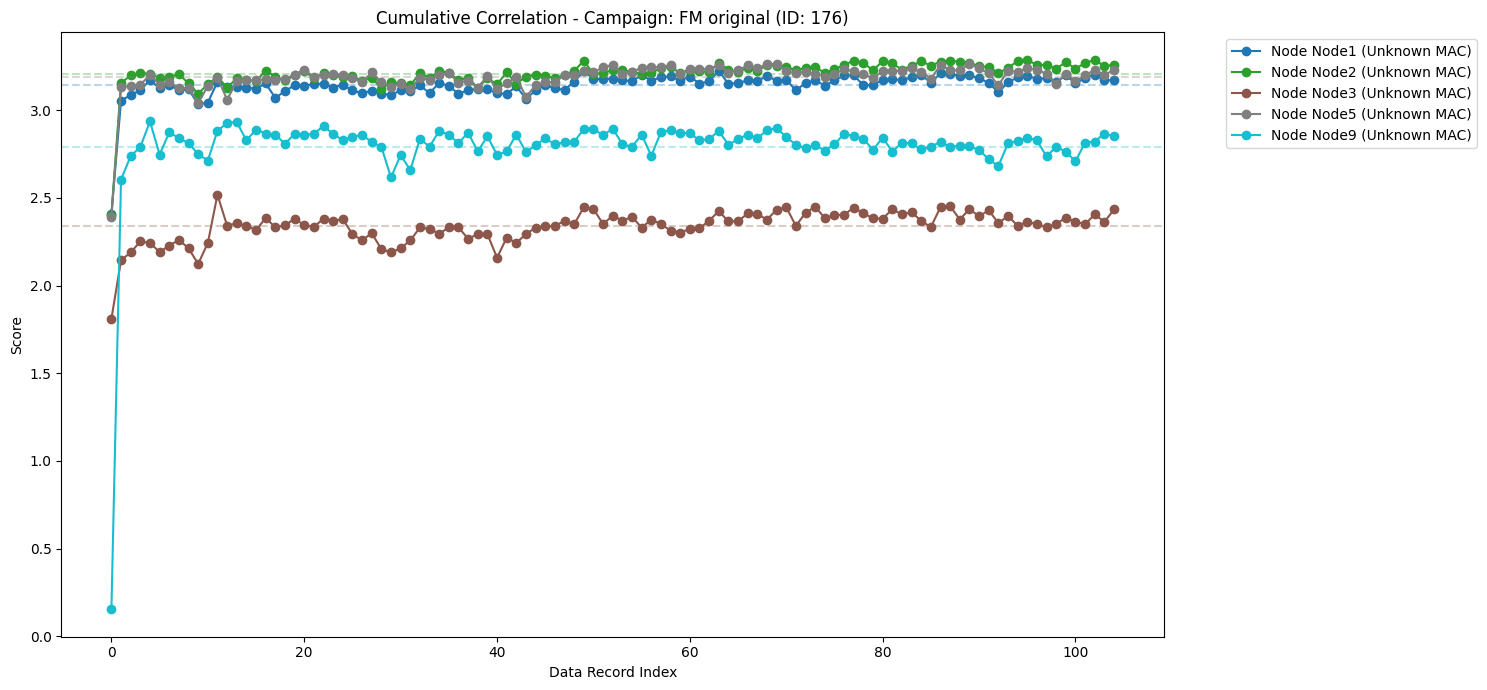

/tmp/ipykernel_124099/2631878390.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_final = plt.cm.get_cmap('viridis', len(campaigns_subset))


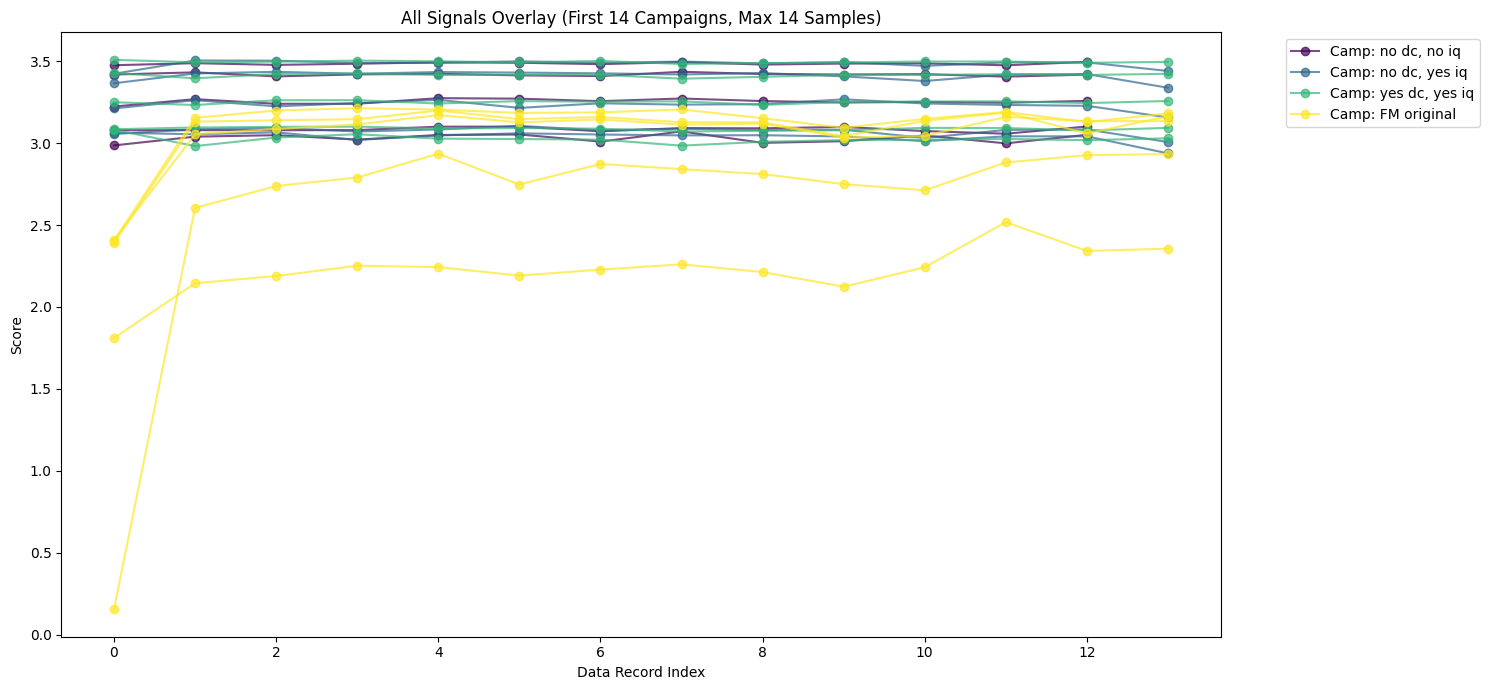

In [5]:
all_campaign_scores = {}

for campaign, camp_id in camp_ids.items():
    datos_nodos = df_full[campaign]
    num_records = min(len(df) for df in datos_nodos.values())
    
    all_ranked_scores = {node: [] for node in datos_nodos.keys()}
    
    for data_record in tqdm(range(num_records), desc=f"Camp: {campaign} (ID: {camp_id})"):
        pxx_indexed = {}
        noise_floor_estimates = {}

        for nombre_nodo, df in datos_nodos.items():
            pxx = np.array(df['pxx'].iloc[data_record]) 
            pxx_indexed[nombre_nodo] = pxx

            counts, bins = np.histogram(pxx, bins=50)
            noise_floor_estimates[nombre_nodo] = bins[np.argmax(counts)]

        global_noise_mean = np.mean(list(noise_floor_estimates.values()))

        pxx_processed = {}
        for nombre_nodo in datos_nodos.keys():
            pxx_orig = pxx_indexed[nombre_nodo]
            offset = global_noise_mean - noise_floor_estimates[nombre_nodo]
            pxx_recentered = pxx_orig + offset
            pxx_processed[nombre_nodo] = (pxx_recentered - np.mean(pxx_recentered)) / (np.std(pxx_recentered) + 1e-8)

        node_names = sorted(datos_nodos.keys())
        n_nodes = len(node_names)
        corr_matrix = np.eye(n_nodes)

        for i in range(n_nodes):
            for j in range(i + 1, n_nodes):
                corr_val, _ = pearsonr(pxx_processed[node_names[i]], pxx_processed[node_names[j]])
                corr_matrix[i, j] = corr_matrix[j, i] = corr_val

        cumulative_scores = np.sum(corr_matrix, axis=1) - 1.0
        
        for node, score in zip(node_names, cumulative_scores):
            all_ranked_scores[node].append(score)

    all_campaign_scores[campaign] = all_ranked_scores
    avg_scores = {node: np.mean(scores) for node, scores in all_ranked_scores.items()}
    
    fig, ax = plt.subplots(figsize=(15, 7))
    cmap = plt.cm.get_cmap('tab10', n_nodes)

    for idx, node in enumerate(node_names):
        mac_label = f"Node {node} ({macs_node.get(str(node), 'Unknown MAC')})"
        
        ax.plot(range(num_records), all_ranked_scores[node], label=mac_label, color=cmap(idx), marker='o')
        ax.axhline(y=avg_scores[node], color=cmap(idx), linestyle='--', alpha=0.3)

    ax.set_title(f"Cumulative Correlation - Campaign: {campaign} (ID: {camp_id})")
    ax.set_xlabel("Data Record Index")
    ax.set_ylabel("Score")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Final plot: All signals in one plot, limit to 14 campaigns, limit samples to 14
fig_final, ax_final = plt.subplots(figsize=(15, 7))
campaigns_subset = list(all_campaign_scores.keys())[:14]
cmap_final = plt.cm.get_cmap('viridis', len(campaigns_subset))

for c_idx, campaign in enumerate(campaigns_subset):
    color = cmap_final(c_idx)
    first_node = True
    for node, scores in all_campaign_scores[campaign].items():
        label = f"Camp: {campaign}" if first_node else None
        ax_final.plot(scores[:14], color=color, alpha=0.7, label=label, marker='o') # Applied [:14] limit here
        first_node = False

ax_final.set_title("All Signals Overlay (First 14 Campaigns, Max 14 Samples)")
ax_final.set_xlabel("Data Record Index")
ax_final.set_ylabel("Score")
ax_final.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()